# Data exploration

## Import libraries and authenticate with API key

In [3]:
import kagglehub
import numpy as np
import pandas as pd

kagglehub.login()

## Download the dataset from kagglehub

In [4]:
from pathlib import Path
path = Path(kagglehub.dataset_download("mariaherrerot/aptos2019"))

print("Path to dataset files:", path)


Path to dataset files: C:\Users\marks\.cache\kagglehub\datasets\mariaherrerot\aptos2019\versions\3


## Load the label files and count the splits

Each split has a CSV with an `id_code` (image name) and a `diagnosis` column holding the diabetic-retinopathy grade (0–4).

In [5]:
train_df = pd.read_csv(path / "train_1.csv")
val_df = pd.read_csv(path / "valid.csv")
test_df = pd.read_csv(path / "test.csv")

splits = {"Train": train_df, "Validation": val_df, "Test": test_df}

# Number of images in each split
for name, df in splits.items():
    print(f"{name:11s}: {len(df):>5d} images")
print(f"{'Total':11s}: {sum(len(df) for df in splits.values()):>5d} images")

Train      :  2930 images
Validation :   366 images
Test       :   366 images
Total      :  3662 images


## Visualize the split sizes

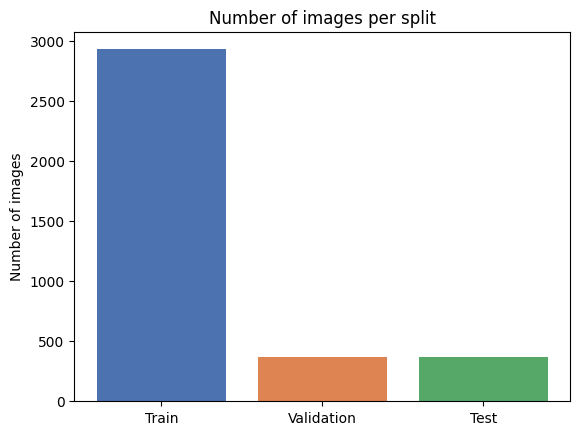

In [ ]:
import matplotlib.pyplot as plt

split_sizes = {name: len(df) for name, df in splits.items()}


plt.bar(split_sizes.keys(), split_sizes.values(),
              color=["#4c72b0", "#dd8452", "#55a868"])

plt.title("Number of images per split")
plt.ylabel("Number of images")

plt.show()

## Visualize the class distribution

The `diagnosis` grade follows the standard APTOS / diabetic-retinopathy scale:

| Grade | Class |
|-------|-------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

                  Train  Validation  Test
No DR              1434         172   199
Mild                300          40    30
Moderate            808         104    87
Severe              154          22    17
Proliferative DR    234          28    33


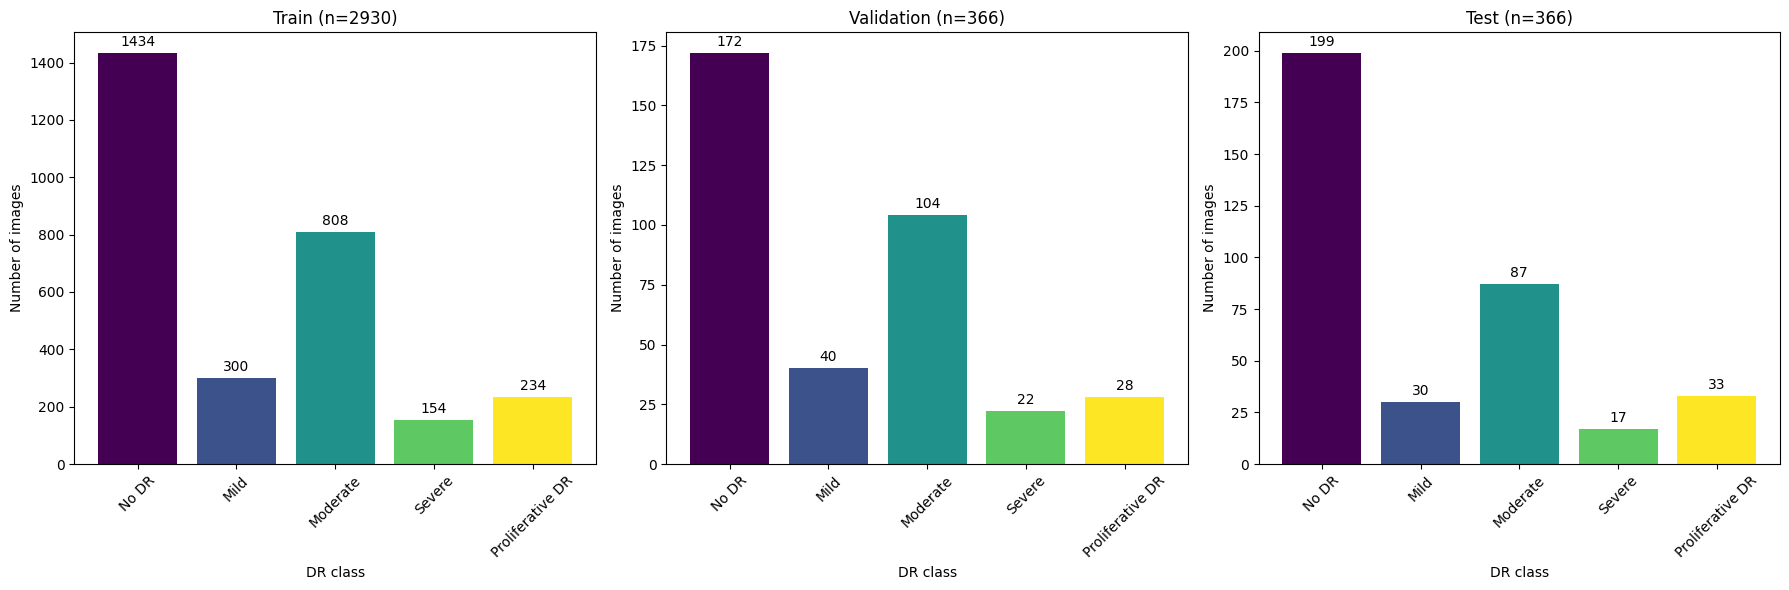

In [12]:
class_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}
classes = list(class_names.keys())

# Count per class for every split (reindex so missing classes show as 0)
dist = pd.DataFrame(
    {name: df["diagnosis"].value_counts().reindex(classes, fill_value=0)
     for name, df in splits.items()}
)
dist.index = [class_names[c] for c in dist.index]
print(dist)

# One subplot per split
fig, axes = plt.subplots(1, len(splits), figsize=(18, 6))
for ax, name in zip(axes, splits):
    bars = ax.bar(dist.index, dist[name], color=plt.cm.viridis(
        [i / (len(classes) - 1) for i in range(len(classes))]))
    ax.set_title(f"{name} (n={dist[name].sum()})")
    ax.set_xlabel("DR class")
    ax.set_ylabel("Number of images")
    ax.bar_label(bars, padding=3)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()